## AI4Climate ML tutorial - Building a machine learning model with gridded data
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

So far we have been working data in tabular format when training machine learning algorithms. We have previously encountered **gridded data**, but previously we converted this into a tabular format before using it with machine learning tools. In this notebook we will instead feed in gridded data into the training and inference of machine learning algorithms to see how working with gridded data is different to working with tabular data.





### Prerequisites 
- Same as previous  notebooks
- Have completed the training pipeline, inference and evaluation notebooks.


### Learning outcomes from completing the notebook

- Understand how to iterate through a gridded dataset for training
- Understand  how to create a convolutional neural network to work with gridded data.
- Understand how to evaluate gridded output for a regression type problem.

## Tutorial - Creating a machine learning pipe

Further Reading
* [PyTorch Docs](https://pytorch.org/)

### Environment 
This notebook uses the environment defined in this repository in the [requirements.txt](../requirements.txt) file (venv) or [requirements.yaml](../requirements.yaml).  

## Tutorial 
a balance of explanation and activity



#### Import libraries
Key libraries for this tutorial include:
- Xarray for loading the input dataset
- scikit learn for preparing the data for training
- pytorch for creating and training the neural network
- matplotlib and cartopy for visualising the results
- scores for evaluating model performance

In [1]:
import pathlib
import os
import datetime
import json
import re

In [2]:
import numpy 
import xarray

In [3]:
import matplotlib
import matplotlib.pyplot
import cartopy.crs

In [4]:
import sklearn
import sklearn.preprocessing
import sklearn.tree


In [5]:
import mlflow

In [6]:
import torch

### Specify the experiment setup

Next we specify the experiment parameters through the config file anmd specifying other elementsm like file paths.

The tutorial config from the JSON file.

In [7]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25a/mmh_storage/ai4c_data/'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer

In [8]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'weatherbench'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'weatherbench'
    return root_path

In [9]:
current_platform = tutorial_config['platform']

In [10]:
current_platform

'jasmin'

In [11]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench')

Define the key parameters for this experiment.

In [12]:
resolution_dict = {5.625: '5.625deg'}

In [13]:
weatherbench_dir = root_data_dir / resolution_dict[5.625]
print(weatherbench_dir.is_dir())
weatherbench_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/5.625deg')

In [14]:
var_list = {
    'temperature': [850, 500],
    'geopotential': [500],
}

In [15]:
era5_rename_lut = {
    'z': 'geopotential',
    't': 'temperature',
}

In [16]:
def get_rename_dict(xr_ds, var_lut):
    vars_present = list(xr_ds.data_vars)
    rename_lut = {k1: v1 for k1,v1 in var_lut.items() if k1 in vars_present}
    return rename_lut
                  

### Create data objects
Next we create a Pytorch dataset class, as we did for the previous tutorial. This is a key area of difference from tabular, because we will and access and prepare the data here quite differently from what we had previously. The class still needs to itersate over the data point, but now instead of rows being data points and columns being features, we have a multi-dimensional aray. Typically in problems like this, the dimensions of the aray correspond to xarray dataset as follows:
- dimension 0 - number of data point in a mini batch
- dimension 1 - the number of variables (also called channels) in a data point.
- dimension 2 - latitude
- dimension 3 - longitude

In [17]:
class WeatherbenchDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, time_period, var_dict, resolution_str, is_train=True, stats_dict = {}):
        self._is_train=is_train

        self._stats_dict = stats_dict
        self._ds_dict = {}

        for current_var, pl_list in var_dict.items():
            for current_pl in pl_list:
                pattern = re.compile(current_var + r"_(\d{4})_5\.625deg\.nc")
                files_to_load = [ f1 for f1 in (data_dir / current_var).iterdir() if pattern.match(f1.name)]
                temp_ds = xarray.open_mfdataset(files_to_load)
                temp_ds = temp_ds.rename(get_rename_dict(temp_ds, era5_rename_lut))
                subset_dict = {
                    'time': slice(time_period[0], time_period[1]),
                    'level': current_pl,
                }
                
                wb_ds = temp_ds.loc[subset_dict]
                var_str = f'{current_var}_{current_pl}'
                var_id = (current_var, current_pl)
                print(var_str)
                self._ds_dict[var_id] = wb_ds

                if is_train:
                    var_stats = (    
                        float(wb_ds[current_var].mean().to_numpy()),
                        float(wb_ds[current_var].std().to_numpy()),
                    )
                    
                    self._stats_dict[var_id] = {'mean': var_stats[0], 'std': var_stats[1]}
                    
        self._time_list = (self._ds_dict[ list(self._ds_dict.keys())[0] ]['time'].values)
        # iterate through dict
        # open dataset for variable
        # subset by level (if multilevel)
        # subset by time 
        #  store pointer to xarray dataset(s) in class for referencing metadata later 
        # if train, calculate mean and std dev, and save to stats dict, with var/level as key
                
        # concat into a numpy array
        

    def __str__(self):
        return str(self._wb_ds)

    def __repr_html__(self):
        return self._wb_ds.__rept_html__()

    def __len__(self):
        return len(self._time_list)

    def __getitem__(self, idx):
        predictors_list = []
        for (var_name, var_pl), ds1 in self._ds_dict.items():
            # get the time for this index
            selected_time = ds1.time[idx].values
            
            select_da = ds1[var_name].loc[{'time': selected_time}]
            var_stats = self._stats_dict[(var_name, var_pl)]
            normal_da = (select_da - var_stats['mean']) / var_stats['std']

            predictors_list += [normal_da.to_numpy()]  
        # deal with idx as a int or a slice consistently        
        if type(idx) == int:
            stack_axis = 0
        else:
            stack_axis=1
        select_array = numpy.stack (
            predictors_list,
            axis=stack_axis, # so that the channels i.e. variables dimension is the last dimension
        )
        select_tensor = torch.tensor(
            select_array,
            dtype=torch.float32,
        )
        return select_tensor



In [18]:
wb_train_ds = WeatherbenchDataset(weatherbench_dir, 
                       (datetime.datetime(1980,1,1,0,0), datetime.datetime(1982,1,1,0,0)), 
                       {'temperature': [850, 500], 'geopotential': [500]}, 
                       resolution_dict[5.625],
                       is_train=True,
                      )

temperature_850
temperature_500
geopotential_500


In [19]:
wb_val_ds = WeatherbenchDataset(weatherbench_dir, 
                                  (datetime.datetime(1983,1,1,0,0), datetime.datetime(1983,2,1,0,0)), 
                                  {'temperature': [850, 500], 'geopotential': [500]}, 
                                  resolution_dict[5.625],
                                  is_train=False,
                                  stats_dict=wb_train_ds._stats_dict
                                 )

temperature_850
temperature_500
geopotential_500


In [20]:
len(wb_train_ds), len(wb_val_ds)

(17545, 745)

In [21]:
wb_train_ds[4].shape

torch.Size([3, 32, 64])

In [22]:
wb_train_ds[:4].shape

torch.Size([4, 3, 32, 64])

In [23]:
wb_train_loader = torch.utils.data.DataLoader(wb_train_ds,
                                           batch_size=4,
                                           shuffle=True,
                                           num_workers=0,
                                          )
wb_train_loader

In [24]:
wb_val_loader = torch.utils.data.DataLoader(wb_val_ds,
                                         batch_size=4,
                                         shuffle=False,
                                         num_workers=0,
                                        )
wb_val_loader

In [25]:
count1 = 0
for X1 in wb_train_loader:
    print(X1.shape)
    count1 +=1
    if count1 > 5:
        break

torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])


### Building a convolutional autoencoder model
For this tutorial we will build an **autoencoder** model. This is an unsupervised technique where we build a model to predict the input. This may sound like a waste of compute, but the idea with autoencoders is to compress the data from a large number of parameters to a smaller bottleneck layer, usually called a **latent space**, which is a compressed representation of the data, and then reinflate the data to the original dimensions. The autoencoder learns how to encoder the data into the latent space and then recostruct the data, idealy perfectly, through a decoder layer. This architecture is the basis for many other models. We can also gain useful insights into the data through exploring the latent space in various ways.

In [26]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [27]:
# latent1 = encoder1(input1)
# latent1.shape

In [28]:
# latent1.view(1,32,8,16).shape

In [29]:
# output1 = decoder1(latent1.view(1,32,8,16))
# output1.shape

In [30]:
class Era5AutoEncoder(torch.nn.Module):
    def __init__(self):
        super(Era5AutoEncoder, self).__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class. 
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial
        self._encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3, 
                            out_channels=16, \
                            kernel_size=3, 
                            padding=1,
                           ),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, stride=2),
            torch.nn.Conv2d(in_channels=16, 
                            out_channels=32, 
                            kernel_size=3, 
                            padding=1,
                           ),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, stride=2),
            torch.nn.Flatten(1,-1)
        )
        self._latent_array_dims = (-1,32,8,16)
        self._decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.Sigmoid(),   
        )



    def forward(self, x):

        # Get latent representation
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent.view(self._latent_array_dims))

        return reconstructed

In [31]:
# Initialize model and move to device
ae_model = Era5AutoEncoder().to(device)

In [32]:
ae_model

Era5AutoEncoder(
  (_encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (_decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Sigmoid()
  )
)

In [33]:
ae_model.forward(wb_train_ds[:4].to(device)).shape

torch.Size([4, 3, 32, 64])

In [34]:
# Loss function and optimizer
loss_function = torch.nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = torch.optim.Adam(ae_model.parameters(), 
                             lr=1e-4)

In [35]:
num_epochs = 5 


In [36]:
%%time
for epoch_num in range(num_epochs):
    print(epoch_num)
    epoch_train_loss = 0.0
    epoch_val_loss = 0.0
    
    for batch_ix, X_batch in enumerate(wb_train_loader):
        print(batch_ix)
        optimizer.zero_grad()
        predictions = ae_model.forward(X_batch.to(device))
        loss_batch = loss_function(predictions, X_batch.to(device))
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= len(wb_train_loader)
    print(epoch_train_loss)
        
        
        
        


0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276


KeyboardInterrupt: 

In [37]:
torch.save(ae_model, 'era5_ae_model.pth')

### Visualise predictions

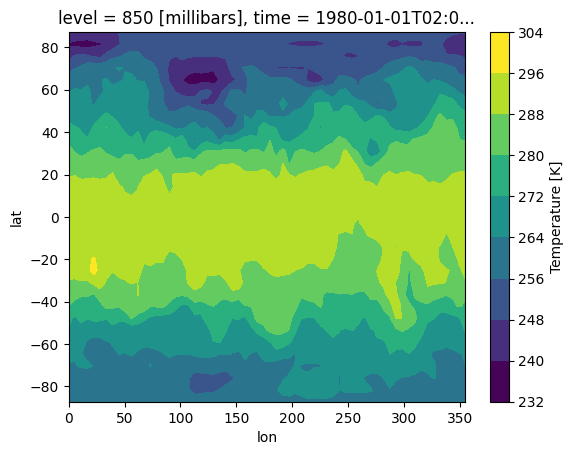

In [38]:
wb_train_ds._ds_dict[('temperature',850)]['temperature'][2].plot.contourf()

create a copy of the xarray data arrray to reuse the metadata for plotting

In [39]:
pred_da = xarray.DataArray(wb_train_ds._ds_dict[('temperature',850)]['temperature'][2])

In [40]:
pred_arr = (ae_model.forward(wb_val_ds[2].to(device)).to('cpu').detach().numpy() * wb_train_ds._stats_dict[('temperature',850)]['std']) + wb_train_ds._stats_dict[('temperature',850)]['mean']

In [42]:
pred_da.values.shape

(32, 64)

In [43]:
pred_da.values = pred_arr[0,0,:]

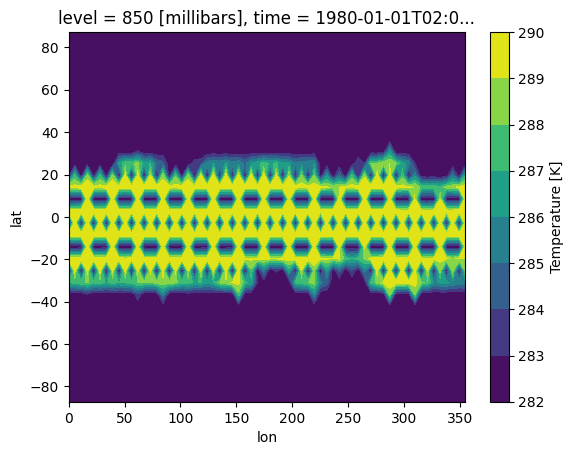

In [44]:
pred_da.plot.contourf()

### Evaluate the results
Now we want to compare our samples to the predictor. We will start looking at RMSE, using the scores package for evaluation.

In [ ]:
import scores

In [ ]:
scores.continuous.rmse(
    ae_model.forward(wb_val_ds[:10].to(device)).to('cpu').detach().numpy(), 
    wb_val_ds[:10].numpy()
)

## Exercises
for students to try that do not have solutions but maybe have an answer or benchmark to facilitate understanding
